# Simulación multiagente: cosecha con Harvesters y Tractores

Reto John Deere / Tec de Monterrey — entrega preliminar.

Campo en grid con un camino de tierra perimetral y central, cultivo con dos
estados (listo / cosechado) y obstáculos aleatorios (2% del cultivo, distintos
en cada corrida). Los `Harvester` cosechan usando A* para moverse y esquivar
obstáculos y a otros agentes; al llenar su capacidad llaman a un `Tractor`,
le vierten la carga y el tractor la lleva al silo.

El modelo vive en `granja.py` (mismo directorio) para poder reutilizarlo
fuera del notebook; aquí lo importamos, corremos y visualizamos.

In [1]:
import agentpy as ap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import HTML

from granja import GranjaModel, PARAMETROS

print("agentpy", ap.__version__)
PARAMETROS

agentpy 0.1.5


{'shape': (40, 40),
 'ancho_camino': 2,
 'pct_obstaculos': 0.02,
 'n_harvesters': 3,
 'n_tractores': 2,
 'tamano_harvester': 2,
 'velocidad_harvester': 1,
 'capacidad_harvester': 25,
 'gasolina_harvester': 1200,
 'consumo_harvester': 1.0,
 'velocidad_tractor': 2,
 'capacidad_tractor': 80,
 'gasolina_tractor': 1500,
 'consumo_tractor': 0.7,
 'tasa_vertido': 8,
 'seed': 1,
 'steps': 1200}

In [2]:
## Corrida sin animación (rápida) — métricas del reto

parametros = dict(PARAMETROS)
parametros['shape'] = (30, 30)
parametros['steps'] = 1500

model = GranjaModel(parametros)
results = model.run()
results.reporters

Completed: 506 steps
Run time: 0:00:00.224196
Simulation finished


,seed,pasos,cosechado_pct,grano_entregado,distancia_total,combustible_usado,giros_totales
0,1,506,100.0,500,1691,1378.7,355


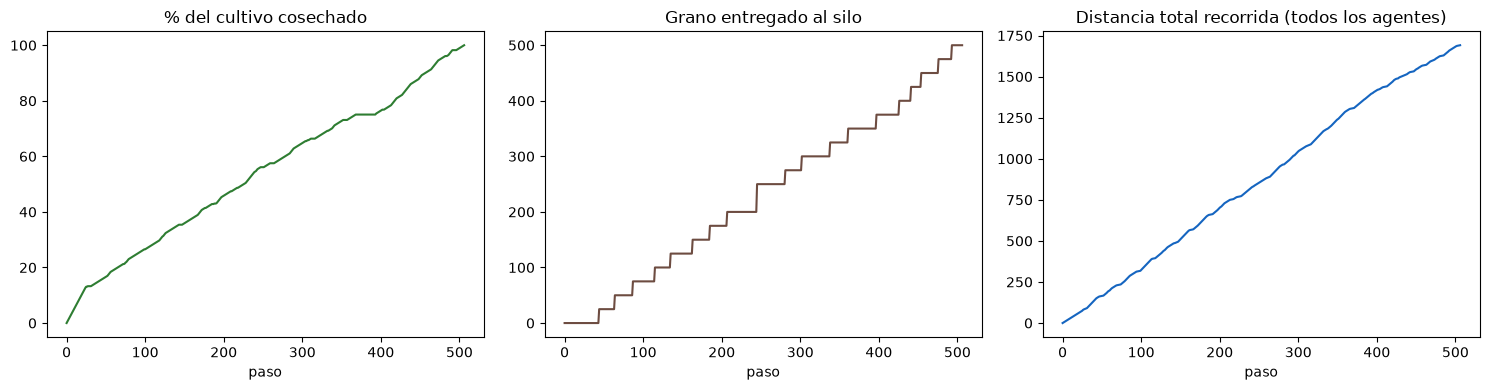

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
data = results.variables.GranjaModel

data['cosechado_pct'].plot(ax=axs[0], color='#2e7d32')
axs[0].set_title('% del cultivo cosechado')
axs[0].set_xlabel('paso')

data['grano_entregado'].plot(ax=axs[1], color='#6d4c41')
axs[1].set_title('Grano entregado al silo')
axs[1].set_xlabel('paso')

data['distancia_total'].plot(ax=axs[2], color='#1565c0')
axs[2].set_title('Distancia total recorrida (todos los agentes)')
axs[2].set_xlabel('paso')

plt.tight_layout()
plt.show()

## Animación

Colores del campo: café = camino de tierra, verde = cultivo listo para
cosechar, dorado = cultivo ya cosechado, gris = obstáculo.
Marcadores: triángulo = Harvester (azul operando, naranja esperando tractor,
morado vertiendo carga), círculo rojo = Tractor, cuadro negro = silo.

In [4]:
CMAP_TERRENO = mcolors.ListedColormap(
    ['#c2a878', '#7cb342', '#c9b458', '#4a4a4a'])  # camino, listo, cosechado, obstaculo

COLOR_HARVESTER = {
    'operando': '#1565c0',
    'esperando_tractor': '#ef6c00',
    'vertiendo': '#6a1b9a',
    'sin_gasolina': '#b71c1c',
}


def dibujar_campo(model, ax):
    ax.clear()
    ax.imshow(model.campo.terreno, cmap=CMAP_TERRENO, vmin=0, vmax=3, origin='upper')

    silo = model.silo
    ax.scatter([silo[1]], [silo[0]], marker='s', c='black', s=140, zorder=5)

    if len(model.harvesters):
        hy = [h.ubicacion[0] for h in model.harvesters]
        hx = [h.ubicacion[1] for h in model.harvesters]
        colores = [COLOR_HARVESTER.get(h.estado, 'gray') for h in model.harvesters]
        ax.scatter(hx, hy, marker='^', c=colores, s=160,
                   edgecolors='white', linewidths=1, zorder=6)

    if len(model.tractores):
        ty = [t.ubicacion[0] for t in model.tractores]
        tx = [t.ubicacion[1] for t in model.tractores]
        ax.scatter(tx, ty, marker='o', c='red', s=120,
                   edgecolors='white', linewidths=1, zorder=6)

    pct = 100 * model.cosechado / model.campo.total_cultivo
    ax.set_title(f"t={model.t}   cosechado={pct:.1f}%   grano entregado={model.entregado}")
    ax.set_xticks([])
    ax.set_yticks([])

In [5]:
parametros_anim = dict(PARAMETROS)
parametros_anim['shape'] = (24, 24)
parametros_anim['steps'] = 500

fig, ax = plt.subplots(figsize=(7, 7))
modelo_anim = GranjaModel(parametros_anim)
animacion = ap.animate(modelo_anim, fig, ax, dibujar_campo)
plt.close(fig)
HTML(animacion.to_jshtml())

### Guardar como GIF

Útil para pegar la animación en el PDF de entrega (el HTML interactivo de
arriba no se exporta a PDF).

In [ ]:
import os

carpeta_gifs = 'GIFS'
os.makedirs(carpeta_gifs, exist_ok=True)
existentes = [f for f in os.listdir(carpeta_gifs) if f.startswith('cosecha_') and f.endswith('.gif')]
numeros = [int(f[len('cosecha_'):-len('.gif')]) for f in existentes if f[len('cosecha_'):-len('.gif')].isdigit()]
siguiente = max(numeros, default=0) + 1

ruta_gif = os.path.join(carpeta_gifs, f'cosecha_{siguiente}.gif')
animacion.save(ruta_gif, writer='pillow', fps=15)
print('guardado:', ruta_gif)